<a href="https://colab.research.google.com/github/seekff/learn-python/blob/main/%E5%B9%B6%E5%8F%91.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**并发 vs 并行（核心概念）**

**并发 Concurrency**

同一时刻只有一个线程执行，但多个线程/任务之间快速切换。

Python 中对应：threading、asyncio。

适用于 I/O 密集型（网络请求、磁盘读写）。

在 Python 中，并发并不是指同一时刻有多个操作（thread、task）同时进行。相反，某个特定的时刻，它只允许有一个操作发生，只不过线程 / 任务之间会互相切换，直到完成。我们来看下面这张图：

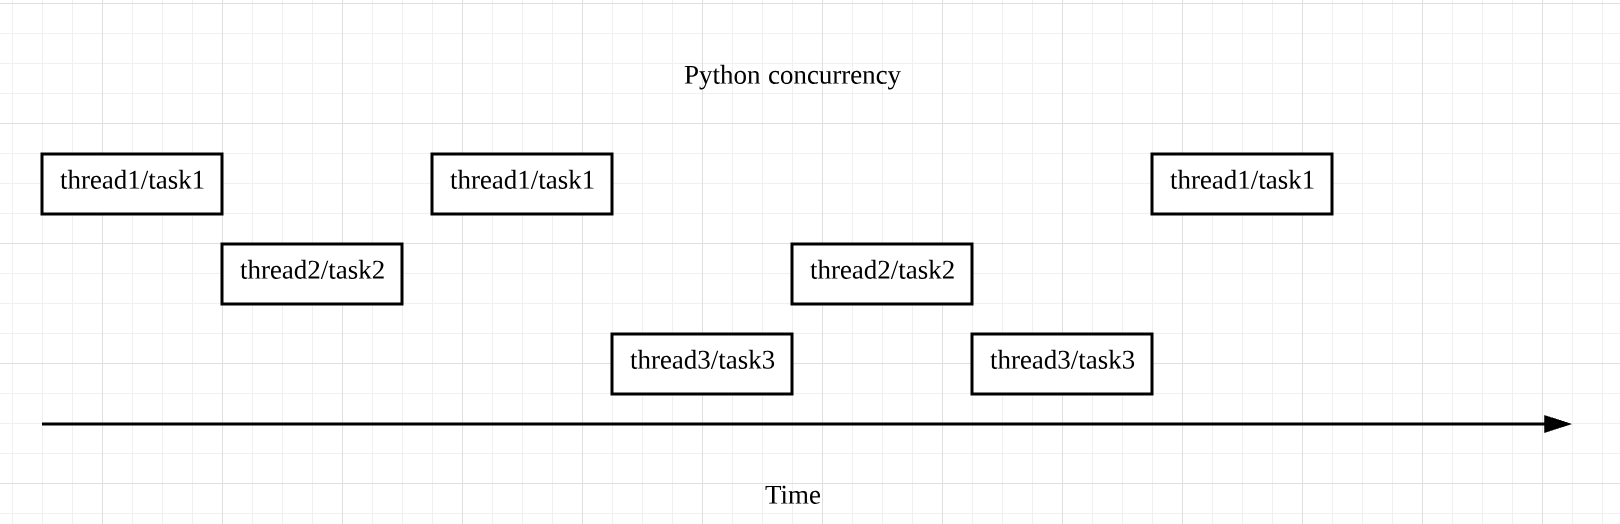



**并行 Parallelism**

多个进程真正同时执行。

Python 中对应：multiprocessing。

适用于 CPU 密集型（计算、图像处理、MapReduce）。

所谓的并行，指的才是同一时刻、同时发生。Python 中的 multi-processing 便是这个意思，对于 multi-processing，你可以简单地这么理解：比如你的电脑是 6 核处理器，那么在运行程序时，就可以强制 Python 开 6 个进程，同时执行，以加快运行速度，它的原理示意图如下：

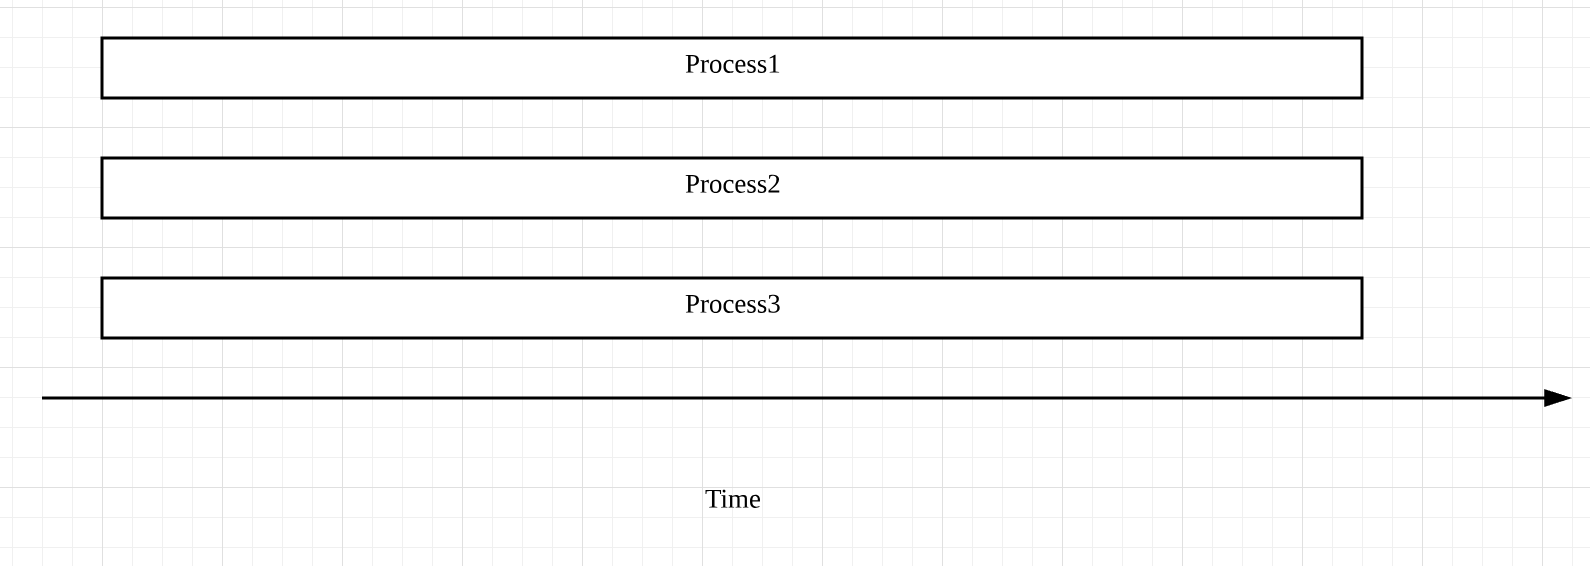

In [ ]:
import requests
import time

def download_one(url):
  resp = requests.get(url)
  print('Read {} from {}'.format(len(resp.content),url))

#单线程
def download_all(sites):
  for site in sites:
    download_one(site)

def main():
  sites = [
        'https://en.wikipedia.org/wiki/Portal:Arts',
        'https://en.wikipedia.org/wiki/Portal:History',
        'https://en.wikipedia.org/wiki/Portal:Society',
        'https://en.wikipedia.org/wiki/Portal:Biography',
        'https://en.wikipedia.org/wiki/Portal:Mathematics',
        'https://en.wikipedia.org/wiki/Portal:Technology',
        'https://en.wikipedia.org/wiki/Portal:Geography',
        'https://en.wikipedia.org/wiki/Portal:Science',
        'https://en.wikipedia.org/wiki/Computer_science',
        'https://en.wikipedia.org/wiki/Python_(programming_language)',
        'https://en.wikipedia.org/wiki/Java_(programming_language)',
        'https://en.wikipedia.org/wiki/PHP',
        'https://en.wikipedia.org/wiki/Node.js',
        'https://en.wikipedia.org/wiki/The_C_Programming_Language',
        'https://en.wikipedia.org/wiki/Go_(programming_language)'
    ]
  start_time = time.perf_counter()
  download_all(sites)
  end_time = time.perf_counter()
  print('Download {} sites in {} seconds'.format(len(sites), end_time - start_time))

if __name__ == '__main__':
  main()



Read 126 from https://en.wikipedia.org/wiki/Portal:Arts
Read 126 from https://en.wikipedia.org/wiki/Portal:History
Read 126 from https://en.wikipedia.org/wiki/Portal:Society
Read 126 from https://en.wikipedia.org/wiki/Portal:Biography
Read 126 from https://en.wikipedia.org/wiki/Portal:Mathematics
Read 126 from https://en.wikipedia.org/wiki/Portal:Technology
Read 126 from https://en.wikipedia.org/wiki/Portal:Geography
Read 126 from https://en.wikipedia.org/wiki/Portal:Science
Read 126 from https://en.wikipedia.org/wiki/Computer_science
Read 126 from https://en.wikipedia.org/wiki/Python_(programming_language)
Read 126 from https://en.wikipedia.org/wiki/Java_(programming_language)
Read 126 from https://en.wikipedia.org/wiki/PHP
Read 126 from https://en.wikipedia.org/wiki/Node.js
Read 126 from https://en.wikipedia.org/wiki/The_C_Programming_Language
Read 126 from https://en.wikipedia.org/wiki/Go_(programming_language)
Download 15 sites in 0.7185889719999068 seconds


In [ ]:
import concurrent.futures
import requests
import threading
import time

def download_one(url):
  resp = requests.get(url)
  print('Read {} from {}'.format(len(resp.content),url))

#多线程
def download_all(sites):
  with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
    executor.map(download_one, sites)

def main():
  sites = [
        'https://en.wikipedia.org/wiki/Portal:Arts',
        'https://en.wikipedia.org/wiki/Portal:History',
        'https://en.wikipedia.org/wiki/Portal:Society',
        'https://en.wikipedia.org/wiki/Portal:Biography',
        'https://en.wikipedia.org/wiki/Portal:Mathematics',
        'https://en.wikipedia.org/wiki/Portal:Technology',
        'https://en.wikipedia.org/wiki/Portal:Geography',
        'https://en.wikipedia.org/wiki/Portal:Science',
        'https://en.wikipedia.org/wiki/Computer_science',
        'https://en.wikipedia.org/wiki/Python_(programming_language)',
        'https://en.wikipedia.org/wiki/Java_(programming_language)',
        'https://en.wikipedia.org/wiki/PHP',
        'https://en.wikipedia.org/wiki/Node.js',
        'https://en.wikipedia.org/wiki/The_C_Programming_Language',
        'https://en.wikipedia.org/wiki/Go_(programming_language)'
    ]
  start_time = time.perf_counter()
  download_all(sites)
  end_time = time.perf_counter()
  print('Download {} sites in {} seconds'.format(len(sites), end_time - start_time))

if __name__ == '__main__':
  main()

Read 126 from https://en.wikipedia.org/wiki/Portal:History
Read 126 from https://en.wikipedia.org/wiki/Portal:Biography
Read 126 from https://en.wikipedia.org/wiki/Portal:Mathematics
Read 126 from https://en.wikipedia.org/wiki/Portal:Society
Read 126 from https://en.wikipedia.org/wiki/Portal:Arts
Read 126 from https://en.wikipedia.org/wiki/Portal:Technology
Read 126 from https://en.wikipedia.org/wiki/Portal:Geography
Read 126 from https://en.wikipedia.org/wiki/Python_(programming_language)
Read 126 from https://en.wikipedia.org/wiki/Portal:Science
Read 126 from https://en.wikipedia.org/wiki/Computer_science
Read 126 from https://en.wikipedia.org/wiki/Java_(programming_language)
Read 126 from https://en.wikipedia.org/wiki/PHP
Read 126 from https://en.wikipedia.org/wiki/Node.js
Read 126 from https://en.wikipedia.org/wiki/The_C_Programming_Language
Read 126 from https://en.wikipedia.org/wiki/Go_(programming_language)
Download 15 sites in 0.22397381000064343 seconds


**单线程 vs 多线程性能对比**

单线程版本

顺序下载 15 个网页，耗时约 0.7s。

大部分时间浪费在 I/O 等待。

**多线程版本（ThreadPoolExecutor）**

使用 5 个线程并发下载，耗时约 0.2s。

性能提升 3 倍以上。

requests.get() 是线程安全的，可放心在多线程中使用。

多进程版本（ProcessPoolExecutor）

适用于 CPU-heavy，不适合 I/O-heavy。

I/O-heavy 场景中，多进程反而可能更慢。

**Futures 的本质与常用 API**

Futures = 对“未来完成的任务”进行封装，可查询状态、获取结果或异常。

常用方法

submit(func, *args)：提交任务，返回 future

future.done()：是否完成（非阻塞）

future.result()：阻塞等待结果或抛异常

as_completed(futures)：按完成顺序返回 future

add_done_callback(fn)：任务完成后自动回调

示例模式

两种常见写法：

① executor.map()（简单、顺序输出）

适合不关心完成顺序的场景。

② submit + as_completed()（按完成顺序处理）

适合需要最快完成的任务优先处理的场景。

In [ ]:
import concurrent.futures
import requests
import threading
import time

def download_one(url):
  resp = requests.get(url)
  print('Read {} from {}'.format(len(resp.content),url))

#多线程
def download_all(sites):
  with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
    to_do = []
    for site in sites:
      future = executor.submit(download_one, site)
      to_do.append(future)

    for future in concurrent.futures.as_completed(to_do):
      future.result()

def main():
  sites = [
        'https://en.wikipedia.org/wiki/Portal:Arts',
        'https://en.wikipedia.org/wiki/Portal:History',
        'https://en.wikipedia.org/wiki/Portal:Society',
        'https://en.wikipedia.org/wiki/Portal:Biography',
        'https://en.wikipedia.org/wiki/Portal:Mathematics',
        'https://en.wikipedia.org/wiki/Portal:Technology',
        'https://en.wikipedia.org/wiki/Portal:Geography',
        'https://en.wikipedia.org/wiki/Portal:Science',
        'https://en.wikipedia.org/wiki/Computer_science',
        'https://en.wikipedia.org/wiki/Python_(programming_language)',
        'https://en.wikipedia.org/wiki/Java_(programming_language)',
        'https://en.wikipedia.org/wiki/PHP',
        'https://en.wikipedia.org/wiki/Node.js',
        'https://en.wikipedia.org/wiki/The_C_Programming_Language',
        'https://en.wikipedia.org/wiki/Go_(programming_language)'
    ]
  start_time = time.perf_counter()
  download_all(sites)
  end_time = time.perf_counter()
  print('Download {} sites in {} seconds'.format(len(sites), end_time - start_time))

if __name__ == '__main__':
  main()

Read 126 from https://en.wikipedia.org/wiki/Portal:Biography
Read 126 from https://en.wikipedia.org/wiki/Portal:Arts
Read 126 from https://en.wikipedia.org/wiki/Portal:Society
Read 126 from https://en.wikipedia.org/wiki/Portal:Mathematics
Read 126 from https://en.wikipedia.org/wiki/Portal:History
Read 126 from https://en.wikipedia.org/wiki/Portal:Geography
Read 126 from https://en.wikipedia.org/wiki/Portal:Technology
Read 126 from https://en.wikipedia.org/wiki/Python_(programming_language)
Read 126 from https://en.wikipedia.org/wiki/Portal:Science
Read 126 from https://en.wikipedia.org/wiki/Computer_science
Read 126 from https://en.wikipedia.org/wiki/Java_(programming_language)
Read 126 from https://en.wikipedia.org/wiki/PHP
Read 126 from https://en.wikipedia.org/wiki/The_C_Programming_Language
Read 126 from https://en.wikipedia.org/wiki/Go_(programming_language)
Read 126 from https://en.wikipedia.org/wiki/Node.js
Download 15 sites in 0.19442347600033827 seconds


**为什么 Python 多线程同一时刻只有一个线程执行？**

因为 GIL（全局解释器锁）：

Python 解释器不是线程安全的

同一时刻只允许一个线程执行 Python 字节码

I/O 阻塞时会释放 GIL → 其他线程继续执行

因此多线程适合 I/O 密集型

**并发 ≠ 并行：前者是切换，后者是真正同时执行**

**I/O-heavy → 多线程；CPU-heavy → 多进程**

Futures 提供任务状态管理、结果获取、异常处理

合理使用线程池可显著提升性能

GIL 限制了多线程的 CPU 并行，但不影响 I/O 并发

**1. 为什么需要 Asyncio（动机）**

多线程虽然能提升 I/O 性能，但存在局限：

线程切换成本高，线程数量不能无限增加

多线程可能出现 race condition

对于 I/O-heavy 且任务数量巨大 的场景，多线程效率仍不够

**Asyncio 诞生就是为了解决这些问题。**

**3. Sync vs Async（核心概念）**

Sync（同步）

操作串行执行

下一个任务必须等待上一个完成

Async（异步）

多个任务可交替执行

某个任务等待 I/O 时，立即切换到其他任务

效率更高，资源利用更充分

**4. Asyncio 的工作原理（Event Loop）**

Asyncio 是 单线程 + 多任务 的模型。

关键机制：Event Loop（事件循环）

Event loop 维护两个任务列表：

预备状态（ready）：可立即执行

等待状态（waiting）：正在等待 I/O 或外部事件

循环过程：

从预备列表中选一个任务执行

任务遇到 await → 把控制权交回 event loop

event loop 检查等待列表：

完成 → 移到预备列表

未完成 → 保持等待

重复执行直到所有任务完成

特点：任务不会被外部打断 → 无 race condition。

**5. Asyncio 的核心用法（代码结构）**

示例：下载 15 个网页内容。

关键语法：async / await

async def：声明协程

await：让出控制权，进入等待状态

创建任务

    tasks = [asyncio.create_task(download_one(site)) for site in sites]

并发执行任务

    await asyncio.gather(*tasks)

运行 event loop

    asyncio.run(download_all(sites))

性能结果
Asyncio 下载 15 个网页耗时 0.06s

明显快于多线程版本（约 0.2s）

In [ ]:
!pip install aiohttp

import asyncio
import aiohttp
import time

async def download_one(url):
  async with aiohttp.ClientSession() as session:
    async with session.get(url) as resp:
      print('Read {} from {}'.format(resp.content_length, url))

async def dowload_all(sites):
  tasks = [asyncio.create_task(download_one(site) for site in sites)]
  await asyncio.gather(*tasks)


def main():
  sites = [
        'https://en.wikipedia.org/wiki/Portal:Arts',
        'https://en.wikipedia.org/wiki/Portal:History',
        'https://en.wikipedia.org/wiki/Portal:Society',
        'https://en.wikipedia.org/wiki/Portal:Biography',
        'https://en.wikipedia.org/wiki/Portal:Mathematics',
        'https://en.wikipedia.org/wiki/Portal:Technology',
        'https://en.wikipedia.org/wiki/Portal:Geography',
        'https://en.wikipedia.org/wiki/Portal:Science',
        'https://en.wikipedia.org/wiki/Computer_science',
        'https://en.wikipedia.org/wiki/Python_(programming_language)',
        'https://en.wikipedia.org/wiki/Java_(programming_language)',
        'https://en.wikipedia.org/wiki/PHP',
        'https://en.wikipedia.org/wiki/Node.js',
        'https://en.wikipedia.org/wiki/The_C_Programming_Language',
        'https://en.wikipedia.org/wiki/Go_(programming_language)'
    ]
  start_time = time.perf_counter()
  asyncio.run(download_all(sites))
  end_time = time.perf_counter()
  print('Download {} sites in {} seconds'.format(len(sites), end_time - start_time))


if __name__ == '__main__':
  main()




**Asyncio 的优势**

单线程，无 race condition

任务切换成本极低

可创建大量任务（远超线程数量）

I/O-heavy 场景性能极强

**Asyncio 的局限**

需要 兼容 Asyncio 的库（如 aiohttp）

requests 不兼容

代码复杂度更高

需要开发者手动管理任务调度（gather、wait、run_until_complete 等）

**多线程 vs Asyncio 的选择指南**

伪代码总结：

    if io_bound:
        if io_slow:
            Use Asyncio
        else:
            Use multi-threading
    else if cpu_bound:
        Use multi-processing

结论：

I/O-heavy + 大量任务 → Asyncio 最优

I/O 快速 + 任务不多 → 多线程即可

CPU-heavy → 多进程